In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/epidemiological-bmi-of-children-by-gender/BMIData.csv


## Title: "Trends in Children's BMI Categories by Gender: An Epidemiological Analysis"

## Import libraries

In [2]:
import pandas as pd
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
import warnings
warnings.filterwarnings('ignore')

## Import dataset

In [4]:
df = pd.read_csv('/kaggle/input/epidemiological-bmi-of-children-by-gender/BMIData.csv')

In [5]:
df.head()

,SchoolYear,NameHospital,Sex,EpiUnderweight,EpiHealthyWeight,EpiOverweight,EpiObese,EpiOverweightAndObese,ValidCounts,UnvalidCounts,TotalCounts
0,2001,Borders,Female,2,334,54,28,82,418,82,500
1,2001,Borders,Male,5,301,63,42,105,411,105,516
2,2001,Lothian,Female,12,728,133,106,239,979,239,1218
3,2001,Lothian,Male,17,681,124,114,238,936,238,1174
4,2001,Fife,Female,17,1361,231,155,386,1764,386,2150


In [6]:
df.tail()

,SchoolYear,NameHospital,Sex,EpiUnderweight,EpiHealthyWeight,EpiOverweight,EpiObese,EpiOverweightAndObese,ValidCounts,UnvalidCounts,TotalCounts
511,2023,Tayside,Male,15,1201,216,178,394,1610,394,2004
512,2023,Greater Glasgow and Clyde,Female,34,4097,595,561,1156,5287,1156,6443
513,2023,Greater Glasgow and Clyde,Male,89,4152,615,641,1256,5497,1256,6753
514,2023,Lanarkshire,Female,14,2255,381,330,711,2980,711,3691
515,2023,Lanarkshire,Male,31,2280,348,381,729,3040,729,3769


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 516 entries, 0 to 515
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   SchoolYear             516 non-null    int64 
 1   NameHospital           516 non-null    object
 2   Sex                    516 non-null    object
 3   EpiUnderweight         516 non-null    int64 
 4   EpiHealthyWeight       516 non-null    int64 
 5   EpiOverweight          516 non-null    int64 
 6   EpiObese               516 non-null    int64 
 7   EpiOverweightAndObese  516 non-null    int64 
 8   ValidCounts            516 non-null    int64 
 9   UnvalidCounts          516 non-null    int64 
 10  TotalCounts            516 non-null    int64 
dtypes: int64(9), object(2)
memory usage: 44.5+ KB


In [8]:
df.describe()

,SchoolYear,EpiUnderweight,EpiHealthyWeight,EpiOverweight,EpiObese,EpiOverweightAndObese,ValidCounts,UnvalidCounts,TotalCounts
count,516.000000,516.000000,516.00000,516.000000,516.000000,516.000000,516.000000,516.000000,516.000000
mean,2013.383721,21.742248,1304.72093,208.102713,175.563953,383.666667,1710.129845,383.666667,2093.796512
std,5.947672,25.207054,1103.90967,167.192486,147.842378,313.523071,1433.191567,313.523071,1743.889989
min,2001.000000,0.000000,7.00000,0.000000,2.000000,2.000000,10.000000,2.000000,12.000000
25%,2009.000000,3.000000,421.75000,66.750000,52.000000,120.500000,549.000000,120.500000,669.500000
50%,2013.500000,13.000000,1158.50000,196.000000,160.500000,350.500000,1558.500000,350.500000,1904.500000
75%,2018.000000,30.000000,1946.25000,292.000000,243.000000,537.000000,2523.250000,537.000000,3038.750000
max,2023.000000,137.000000,4623.00000,696.000000,737.000000,1433.000000,6150.000000,1433.000000,7583.000000


In [9]:
df.isnull().sum()

SchoolYear               0
NameHospital             0
Sex                      0
EpiUnderweight           0
EpiHealthyWeight         0
EpiOverweight            0
EpiObese                 0
EpiOverweightAndObese    0
ValidCounts              0
UnvalidCounts            0
TotalCounts              0
dtype: int64

In [10]:
df.duplicated().sum()

0

In [11]:
df.corr

<bound method DataFrame.corr of      SchoolYear               NameHospital     Sex  EpiUnderweight  \
0          2001                    Borders  Female               2   
1          2001                    Borders    Male               5   
2          2001                    Lothian  Female              12   
3          2001                    Lothian    Male              17   
4          2001                       Fife  Female              17   
..          ...                        ...     ...             ...   
511        2023                    Tayside    Male              15   
512        2023  Greater Glasgow and Clyde  Female              34   
513        2023  Greater Glasgow and Clyde    Male              89   
514        2023                Lanarkshire  Female              14   
515        2023                Lanarkshire    Male              31   

     EpiHealthyWeight  EpiOverweight  EpiObese  EpiOverweightAndObese  \
0                 334             54        28        

In [12]:
df.columns

Index(['SchoolYear', 'NameHospital', 'Sex', 'EpiUnderweight',
       'EpiHealthyWeight', 'EpiOverweight', 'EpiObese',
       'EpiOverweightAndObese', 'ValidCounts', 'UnvalidCounts', 'TotalCounts'],
      dtype='object')

## Data visualization

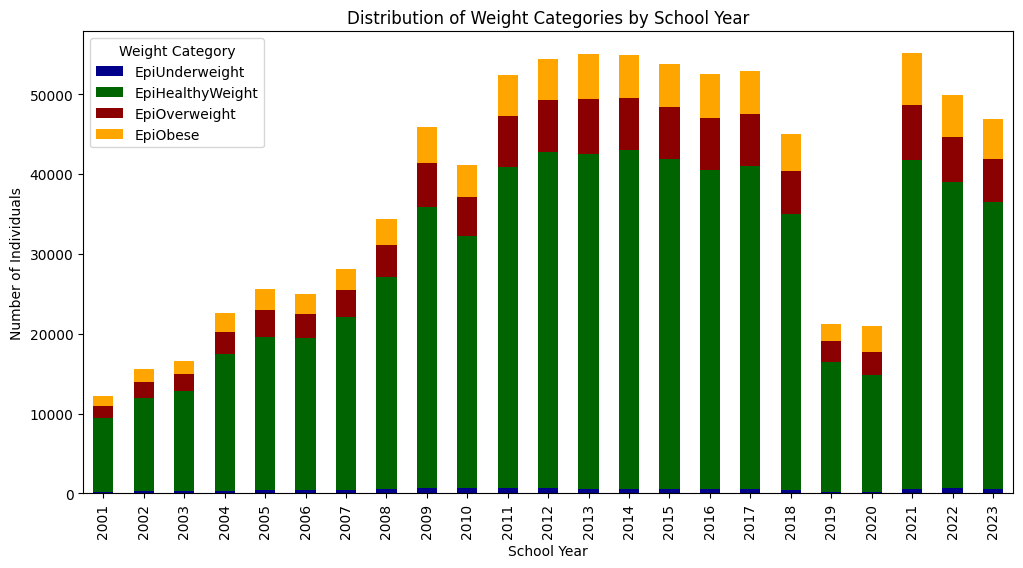

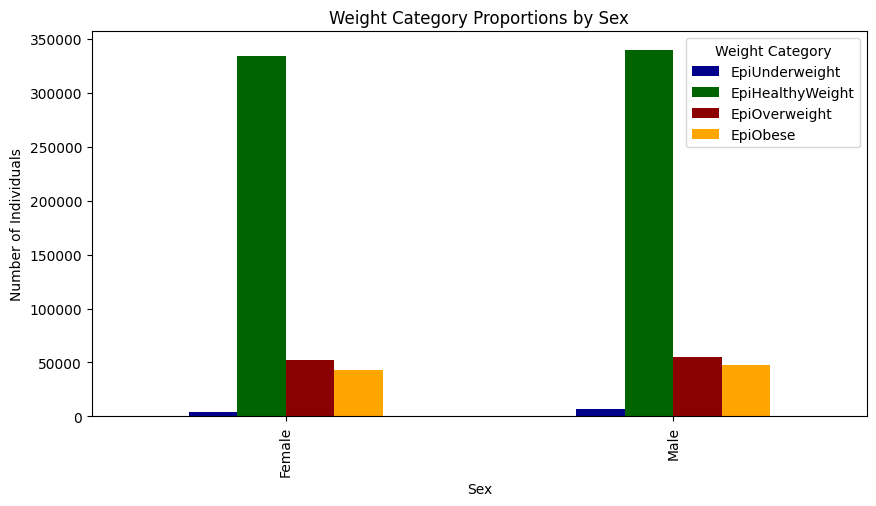

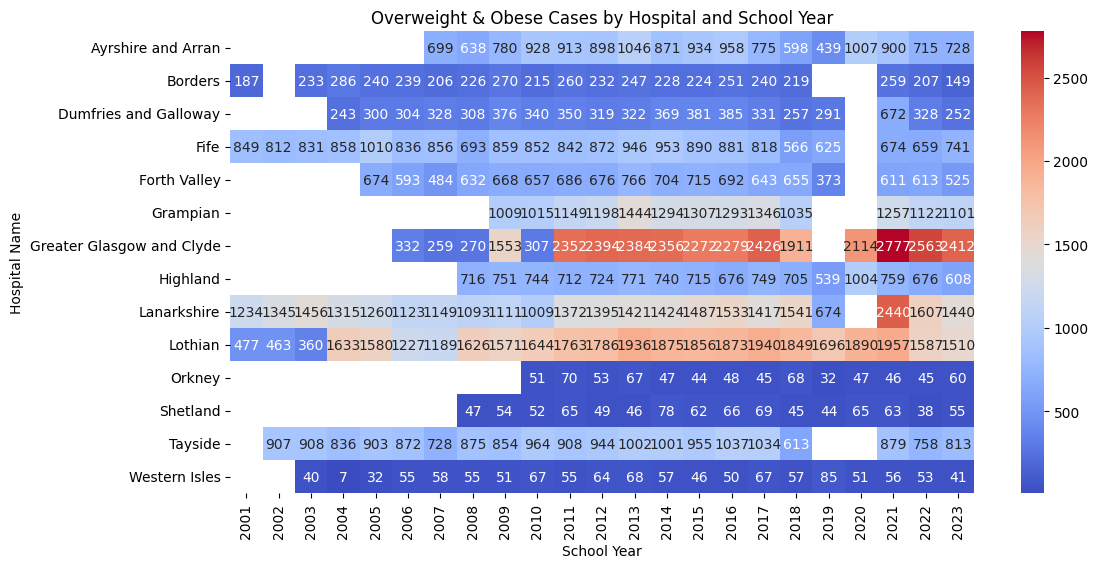

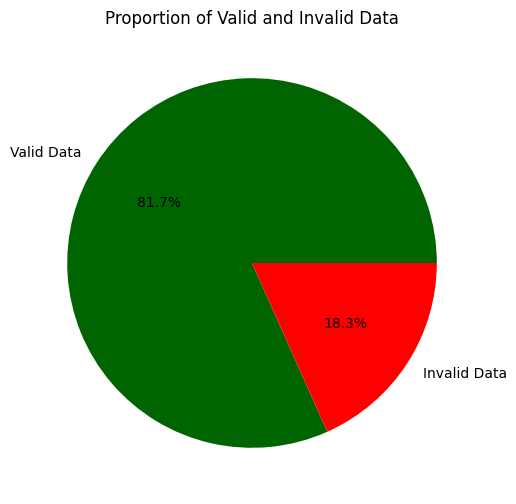

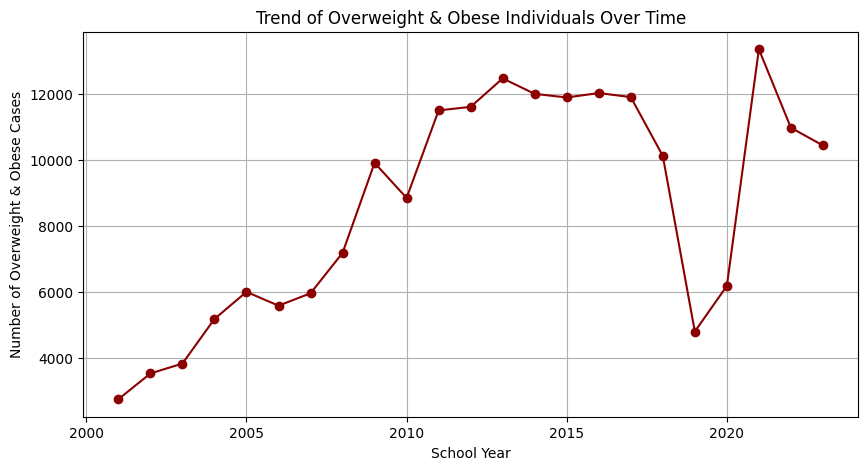

In [13]:
# Set color palette
colors = ["darkblue", "darkgreen", "darkred", "orange"]

# 1. Stacked Bar Chart: Distribution of Weight Categories by School Year
df_grouped = df.groupby("SchoolYear")[["EpiUnderweight", "EpiHealthyWeight", "EpiOverweight", "EpiObese"]].sum()
df_grouped.plot(kind="bar", stacked=True, figsize=(12,6), color=colors)
plt.title("Distribution of Weight Categories by School Year")
plt.xlabel("School Year")
plt.ylabel("Number of Individuals")
plt.legend(title="Weight Category")
plt.show()

# 2. Grouped Bar Chart: Weight Category Proportions by Sex
df_sex_grouped = df.groupby("Sex")[["EpiUnderweight", "EpiHealthyWeight", "EpiOverweight", "EpiObese"]].sum()
df_sex_grouped.plot(kind="bar", figsize=(10,5), color=colors)
plt.title("Weight Category Proportions by Sex")
plt.xlabel("Sex")
plt.ylabel("Number of Individuals")
plt.legend(title="Weight Category")
plt.show()

# 3. Heatmap: Overweight and Obesity Rates by Hospital and School Year
# Aggregate duplicate rows by summing values
df_agg = df.groupby(["NameHospital", "SchoolYear"])["EpiOverweightAndObese"].sum().reset_index()

# Create pivot table
df_pivot = df_agg.pivot(index="NameHospital", columns="SchoolYear", values="EpiOverweightAndObese")

# Plot heatmap
plt.figure(figsize=(12, 6))
sns.heatmap(df_pivot, cmap="coolwarm", annot=True, fmt=".0f")
plt.title("Overweight & Obese Cases by Hospital and School Year")
plt.xlabel("School Year")
plt.ylabel("Hospital Name")
plt.show()

# 4. Pie Chart: Valid vs Invalid Data
plt.figure(figsize=(6,6))
plt.pie(df[["ValidCounts", "UnvalidCounts"]].sum(), labels=["Valid Data", "Invalid Data"], autopct='%1.1f%%', colors=["darkgreen", "red"])
plt.title("Proportion of Valid and Invalid Data")
plt.show()

# 5. Line Chart: Overweight & Obese Trends Over Time
df_trend = df.groupby("SchoolYear")["EpiOverweightAndObese"].sum()
plt.figure(figsize=(10,5))
plt.plot(df_trend.index, df_trend.values, marker="o", linestyle="-", color="darkred")
plt.title("Trend of Overweight & Obese Individuals Over Time")
plt.xlabel("School Year")
plt.ylabel("Number of Overweight & Obese Cases")
plt.grid(True)
plt.show()

## EDA

In [14]:
median_obese = df['EpiObese'].median()
df['HighObesity'] = (df['EpiObese'] > median_obese).astype(int)

In [15]:
print(f"Median of EpiObese: {median_obese}")
print('Value counts for HighObesity:')
print(df['HighObesity'].value_counts())

Median of EpiObese: 160.5
Value counts for HighObesity:
HighObesity
0    258
1    258
Name: count, dtype: int64


In [16]:
features = ['SchoolYear', 'EpiUnderweight', 'EpiHealthyWeight', 'EpiOverweight', 'EpiOverweightAndObese', 'ValidCounts', 'UnvalidCounts', 'TotalCounts']

## Train test splitting

In [17]:
X = df[features]
y = df['HighObesity']

## ML Algorithms

In [18]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.neural_network import MLPClassifier

In [19]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [20]:
# Normalize numerical features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [21]:
models = {
    "Logistic Regression": LogisticRegression(),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "Support Vector Machine": SVC(),
    "K-Nearest Neighbors": KNeighborsClassifier(),
    "Decision Tree": DecisionTreeClassifier(),
    "Naive Bayes": GaussianNB(),
    "Gradient Boosting": GradientBoostingClassifier(),
    "AdaBoost": AdaBoostClassifier(),
    "Extra Trees": ExtraTreesClassifier(),
    "Neural Network": MLPClassifier(max_iter=500)
}

In [22]:
results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc
    print(f"{name}: {acc:.4f}")

# Sort models by accuracy
sorted_results = sorted(results.items(), key=lambda x: x[1], reverse=True)
print("\nSorted Results:")
for name, acc in sorted_results:
    print(f"{name}: {acc:.4f}")

Logistic Regression: 0.9032
Random Forest: 0.9613
Support Vector Machine: 0.8903
K-Nearest Neighbors: 0.9097
Decision Tree: 0.9548
Naive Bayes: 0.8903
Gradient Boosting: 0.9548
AdaBoost: 0.9613
Extra Trees: 0.9419
Neural Network: 0.9226

Sorted Results:
Random Forest: 0.9613
AdaBoost: 0.9613
Decision Tree: 0.9548
Gradient Boosting: 0.9548
Extra Trees: 0.9419
Neural Network: 0.9226
K-Nearest Neighbors: 0.9097
Logistic Regression: 0.9032
Support Vector Machine: 0.8903
Naive Bayes: 0.8903


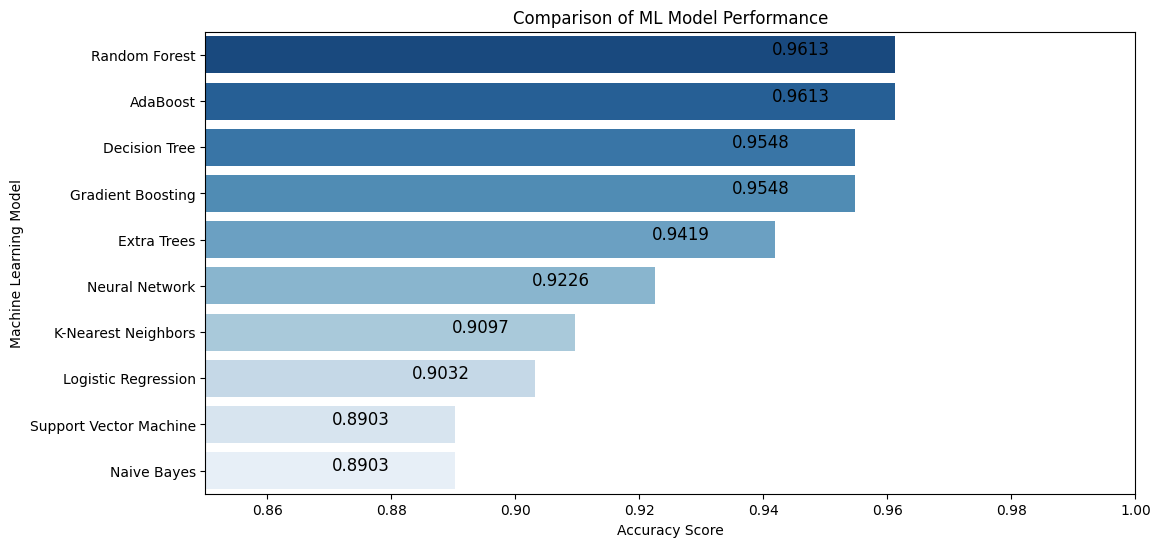

In [23]:
results_df = pd.DataFrame(sorted_results, columns=["Model", "Accuracy"])
plt.figure(figsize=(12, 6))
sns.barplot(x="Accuracy", y="Model", data=results_df, palette="Blues_r")
plt.xlabel("Accuracy Score")
plt.ylabel("Machine Learning Model")
plt.title("Comparison of ML Model Performance")
plt.xlim(0.85, 1.0)  # Adjust based on accuracy range
for index, value in enumerate(results_df["Accuracy"]):
    plt.text(value - 0.02, index, f"{value:.4f}", color="black", fontsize=12)
plt.show()

## Thank you....pls upvote!!!!